In [1]:
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model='gpt-4o')
small_llm = ChatOpenAI(model='gpt-4o-mini')

In [3]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph

class AgentState(TypedDict):
    query: str
    context: list
    answer: str

graph_builder = StateGraph(AgentState)

In [4]:
from langchain_core.prompts import ChatPromptTemplate
from pydantic import BaseModel, Field
from typing import Literal

class Route(BaseModel):
    target: Literal['income_tax', 'llm', 'real_estate_tax'] = Field(
        description="The target for the query to answer"
    )

router_system_prompt = """
You are an expert at routing a user's question to 'income_tax', 'llm', or 'real_estate_tax'.
'income_tax' contains information about income tax up to May 2026.
'real_estate_tax' contains information about real estate tax up to May 2026.
if you think the question is not related to either 'income_tax' or 'real_estate_tax';
you can route it to 'llm'."""

router_prompt = ChatPromptTemplate.from_messages([
    ('system', router_system_prompt),
    ('user', '{query}')
])

structured_router_llm = small_llm.with_structured_output(Route)

def router(state: AgentState):
    query = state['query']
    router_chain = router_prompt | structured_router_llm
    route = router_chain.invoke({'query': query})
    print(f'router route == {route}')
    print(f'route.target == {route.target}')
    return route.target

In [5]:
from langchain_core.output_parsers import StrOutputParser

def call_llm(state: AgentState):
    query    = state['query']
    llm_chain = small_llm | StrOutputParser()
    llm_answer = llm_chain.invoke(query)
    return {'answer': llm_answer}

In [6]:
from income_tax_graph import graph as income_tax_agent
from real_esatate_tax_graph import graph as real_esatate_tax_agent

graph_builder.add_node('income_tax', income_tax_agent)
graph_builder.add_node('real_estate_tax', real_esatate_tax_agent)
graph_builder.add_node('llm', call_llm)

answer == {'answer': '연봉 5천만 원인 거주자의 소득세는 624만 원입니다. 5천만 원 이하의 소득에 대해 해당하는 세율은 1,400만 원을 초과하는 금액의 24%를 추가로 더한 금액이기 때문에, 최종 계산된 소득세는 624만 원입니다.'}
tax_base == 사용자가 보유한 주택의 공시가격 합계를 계산하면 다음과 같습니다:

5억 + 10억 + 20억 = 35억 원

사용자가 여러 채의 집을 보유하고 있으므로 9억 원이 공제됩니다. 

과세표준을 계산하면 다음과 같습니다:

\((35억 - 9억) × 0.6 = 26억 × 0.6 = 15억 6천만 원\)

따라서, 과세표준은 15억 6천만 원이 됩니다. 

이 과세표준에 따라 종합부동산세가 부과됩니다. 세율은 과세표준에 따라 달라지므로 구체적인 세율을 알아야 정확한 세금을 계산할 수 있습니다.
tax_rate == 사용자가 소유한 주택 수는 3채이므로, 3주택 이상 소유한 경우의 종합부동산세율을 적용해야 합니다. 
   
계산된 과세표준은 15.6억 원입니다. 이에 따라 세율을 적용하여 종합부동산세를 계산합니다.

3주택 이상 소유한 경우, 과세표준이 12억 원 초과 25억 원 이하 구간에 해당합니다. 세율은 다음과 같습니다:

- 960만 원 + (12억 원을 초과하는 금액의 1천분의 20)

계산은 다음과 같습니다:

과세표준 초과액: 15.6억 원 - 12억 원 = 3.6억 원

세액: 960만 원 + (3.6억 원 × 1천분의 20) = 960만 원 + 720만 원 = 1,680만 원

따라서 사용자는 1,680만 원의 종합부동산세를 납부해야 합니다.


In [7]:
from langgraph.graph import START, END

graph_builder.add_conditional_edges(
    START,
    router,
    {
        'income_tax': 'income_tax',
        'real_estate_tax': 'real_estate_tax',
        'llm': 'llm',
    }
)
graph_builder.add_edge('income_tax', END)
graph_builder.add_edge('real_estate_tax', END)
graph_builder.add_edge('llm', END)

In [8]:
graph = graph_builder.compile()

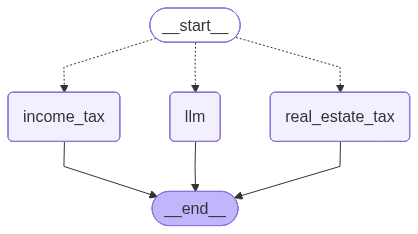

In [9]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [10]:
# initial_state = {'query': '소득세란 무엇인가요?'}
# graph.invoke(initial_state)

In [11]:
# initial_state = {'query': '집 15억은 세금을 얼마나 내나요?'}
# graph.invoke(initial_state)

In [12]:
initial_state = {'query': '떡볶이는 어디가 맛있나요?'}
graph.invoke(initial_state)

router route == target='llm'
route.target == llm


{'query': '떡볶이는 어디가 맛있나요?',
 'answer': '떡볶이는 한국의 대표적인 길거리 음식으로, 맛있게 만드는 곳이 많이 있습니다. 지역에 따라 유명한 떡볶이 맛집이 다를 수 있는데요, 몇 가지 추천드릴게요.\n\n1. **신당동 떡볶이**: 서울의 신당동은 떡볶이 거리로 유명하며, 다양한 떡볶이 가게들이 모여 있습니다. 특히 소문난 집들이 많으니 여러 곳을 비교해보는 것도 좋습니다.\n\n2. **홍대 떡볶이**: 젊은 사람들이 많이 찾는 홍대에도 맛있고 창의적인 떡볶이 가게들이 많습니다. 다양한 토핑과 소스를 시도해볼 수 있습니다.\n\n3. **부산의 밀면 떡볶이**: 부산에서는 떡볶이와 밀면을 함께 제공하는 곳도 있어 색다른 맛을 경험해볼 수 있습니다.\n\n4. **전주 비빔떡볶이**: 전주의 비빔떡볶이는 달콤하고 매콤한 양념과 함께 제공되며, 지역 특색을 느낄 수 있는 메뉴입니다.\n\n각 지역마다 특색이 있으니, 여행이나 외출 시 근처의 인기 떡볶이 가게를 찾아보는 것도 추천드립니다!'}